# Causal Tracing 

In [1]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
from logitlense import BERTLogitLens
from CausalTracingFrobenius import CausalTracingAnalyzer
import pandas as pd

/u/gakgul/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the Models

In [3]:
from transformers import AutoModelForMaskedLM, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# English models
model_language_en = AutoModelForMaskedLM.from_pretrained("/u/gakgul/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_language.pth", local_files_only=True).to(device)
model_semantic_en = AutoModelForMaskedLM.from_pretrained("/u/gakgul/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_semantic.pth", local_files_only=True).to(device)
model_whole_en = AutoModelForMaskedLM.from_pretrained("/u/gakgul/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en.pth", local_files_only=True).to(device)
model_base_en = AutoModelForMaskedLM.from_pretrained("bert-base-uncased").to(device)

# Chinese models
model_language_zh = AutoModelForMaskedLM.from_pretrained("/u/gakgul/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh_language.pth", local_files_only=True).to(device)
model_semantic_zh = AutoModelForMaskedLM.from_pretrained("/u/gakgul/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh_semantic.pth", local_files_only=True).to(device)
model_whole_zh = AutoModelForMaskedLM.from_pretrained("/u/gakgul/Documents/Anuja/for_Frodo/weights/bert-chinese_finetuned_end2end_all_nt_COL_zh.pth", local_files_only=True).to(device)
model_base_zh = AutoModelForMaskedLM.from_pretrained("bert-base-chinese").to(device)

# Tokenizers as before
tokenizer_zh = AutoTokenizer.from_pretrained("bert-base-chinese", use_fast=True)
tokenizer_en = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)


Some weights of BertForMaskedLM were not initialized from the model checkpoint at /u/gakgul/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_language.pth and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForMaskedLM were not initialized from the model checkpoint at /u/gakgul/Documents/Anuja/for_Frodo/weights/bert-base_finetuned_end2end_all_nt_COL_en_semantic.pth and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should prob

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_configs_en = {
    'BERT-Base-EN': {'model': model_base_en, 'tokenizer': tokenizer_en, 'language': 'English'},
    'BERT-FT-Language-EN': {'model': model_language_en, 'tokenizer': tokenizer_en, 'language': 'English'},
    'BERT-FT-Semantic-EN': {'model': model_semantic_en, 'tokenizer': tokenizer_en, 'language': 'English'},
    'BERT-FT-Whole-EN': {'model': model_whole_en, 'tokenizer': tokenizer_en, 'language': 'English'},
}

model_configs_zh = {
    'BERT-Base-ZH': {'model': model_base_zh, 'tokenizer': tokenizer_zh, 'language': 'Chinese'},
    'BERT-FT-Language-ZH': {'model': model_language_zh, 'tokenizer': tokenizer_zh, 'language': 'Chinese'},
    'BERT-FT-Semantic-ZH': {'model': model_semantic_zh, 'tokenizer': tokenizer_zh, 'language': 'Chinese'},
    'BERT-FT-Whole-ZH': {'model': model_whole_zh, 'tokenizer': tokenizer_zh, 'language': 'Chinese'},
}

# Load the Data

In [5]:
import sys
sys.path.insert(0, "/u/gakgul/Documents/Anuja/mlama")  
from dataset.reader import MLama
def collect_prompts_answers_all_relations(data_folder, languages=['en', 'zh'], mask_token='[MASK]'):
    mlama = MLama(data_folder)
    mlama.load()
    facts_by_relation_and_language = {}

    for lang in languages:
        for relation, entry in mlama.data[lang].items():
            # entry has keys 'template', 'triples'
            template = entry['template']
            prompts = {}
            for triple in entry['triples'].values():
                prompt = template.replace('[X]', triple['sub_label']).replace('[Y]', mask_token)
                answer = triple['obj_label']
                prompts[prompt] = answer
            facts_by_relation_and_language[f"{relation}-{lang}"] = prompts
    return facts_by_relation_and_language

data_folder = '/u/gakgul/Documents/Anuja/data/mlama1.1/' 
facts_dict = collect_prompts_answers_all_relations(data_folder)

In [6]:
def build_fact_list(fact_dict, relation_type='capital'):
    fact_list = []
    for prompt, answer in fact_dict.items():
        if relation_type == 'capital':
            # Extract country/city/etc from "The capital of XYZ is [MASK] ."
            try:
                subject = prompt.split('of ')[1].split(' is')[0].strip()
            except Exception:
                subject = ''
        elif relation_type == 'official language':
            try:
                subject = prompt.split('of ')[1].split(' is')[0].strip()
            except Exception:
                subject = ''
        elif relation_type == 'currency':
            try:
                subject = prompt.split('of ')[1].split(' is')[0].strip()
            except Exception:
                subject = ''
        else:
            subject = ''
        fact_list.append({'prompt': prompt, 'subject': subject, 'target': answer})
    return fact_list


In [7]:
facts_capital_en = build_fact_list(facts_dict['P36-en'], relation_type='capital')
facts_language_en = build_fact_list(facts_dict['P37-en'], relation_type='official language')


facts_capital_zh = build_fact_list(facts_dict['P36-zh'], relation_type='capital')
facts_language_zh = build_fact_list(facts_dict['P37-zh'], relation_type='official language')

first100_facts_capital_en = facts_capital_en[:100]
first100_facts_language_en = facts_language_en[:100]
first100_facts_capital_zh = facts_capital_zh[:100]
first100_facts_language_zh = facts_language_zh[:100]

# Capitals

## BERT-Base-EN


=== BERT-Base-EN (EN): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


Completed 100 facts. Average scores stored.


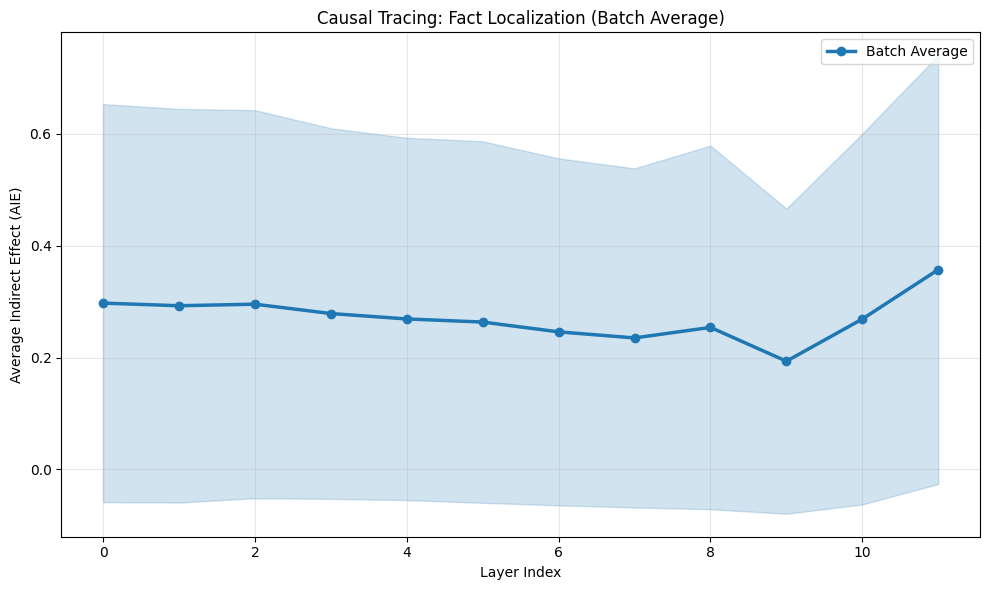

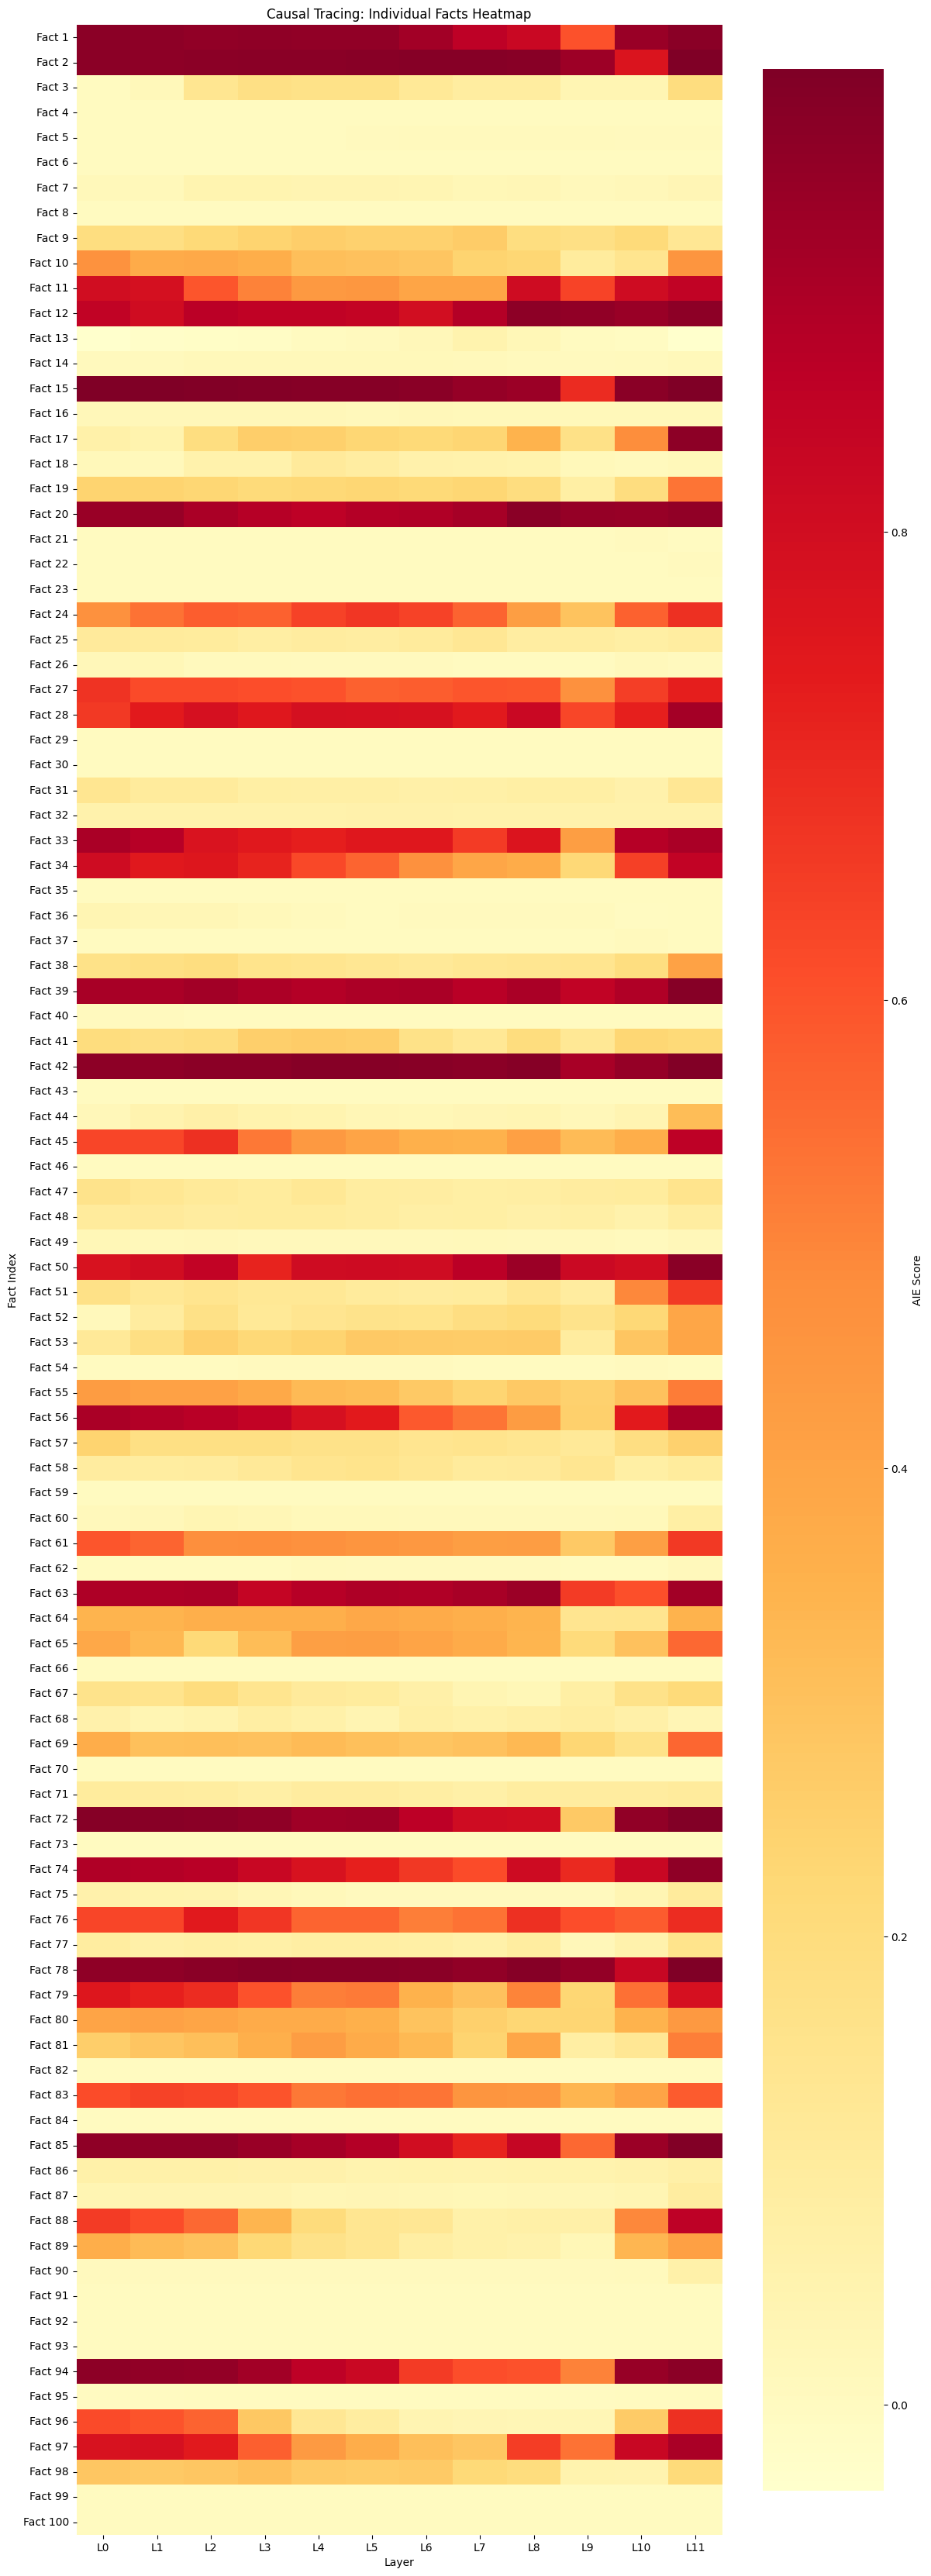

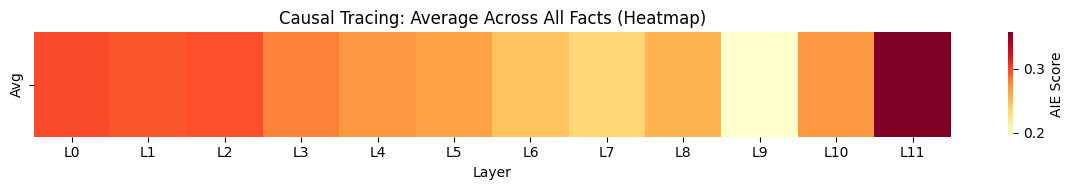

{'peak_layer': 11, 'peak_score': 0.35715864502348815, 'early_layer_avg': 0.2909980856586376, 'mid_layer_avg': 0.2533621480573684, 'late_layer_avg': 0.2683380892625005, 'total_impact': 3.250793291914026}


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-Base-EN'
config = model_configs_en[model_label]

print(f"\n=== {model_label} (EN): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_en, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_EN_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_EN_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_EN_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-FT-Language-EN


=== BERT-FT-Language-EN (EN): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [01:31<00:00,  1.09it/s]


Completed 100 facts. Average scores stored.


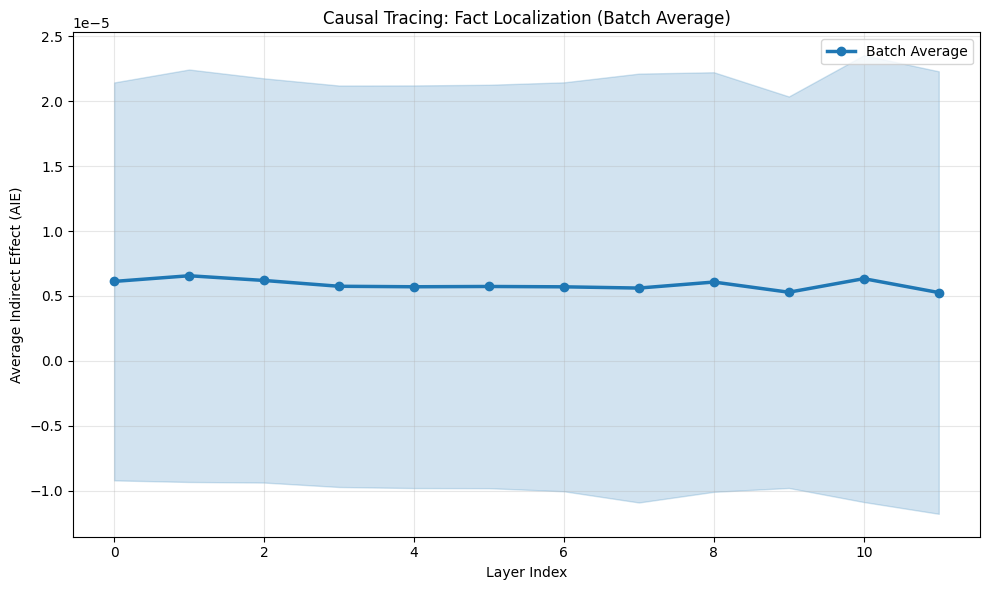

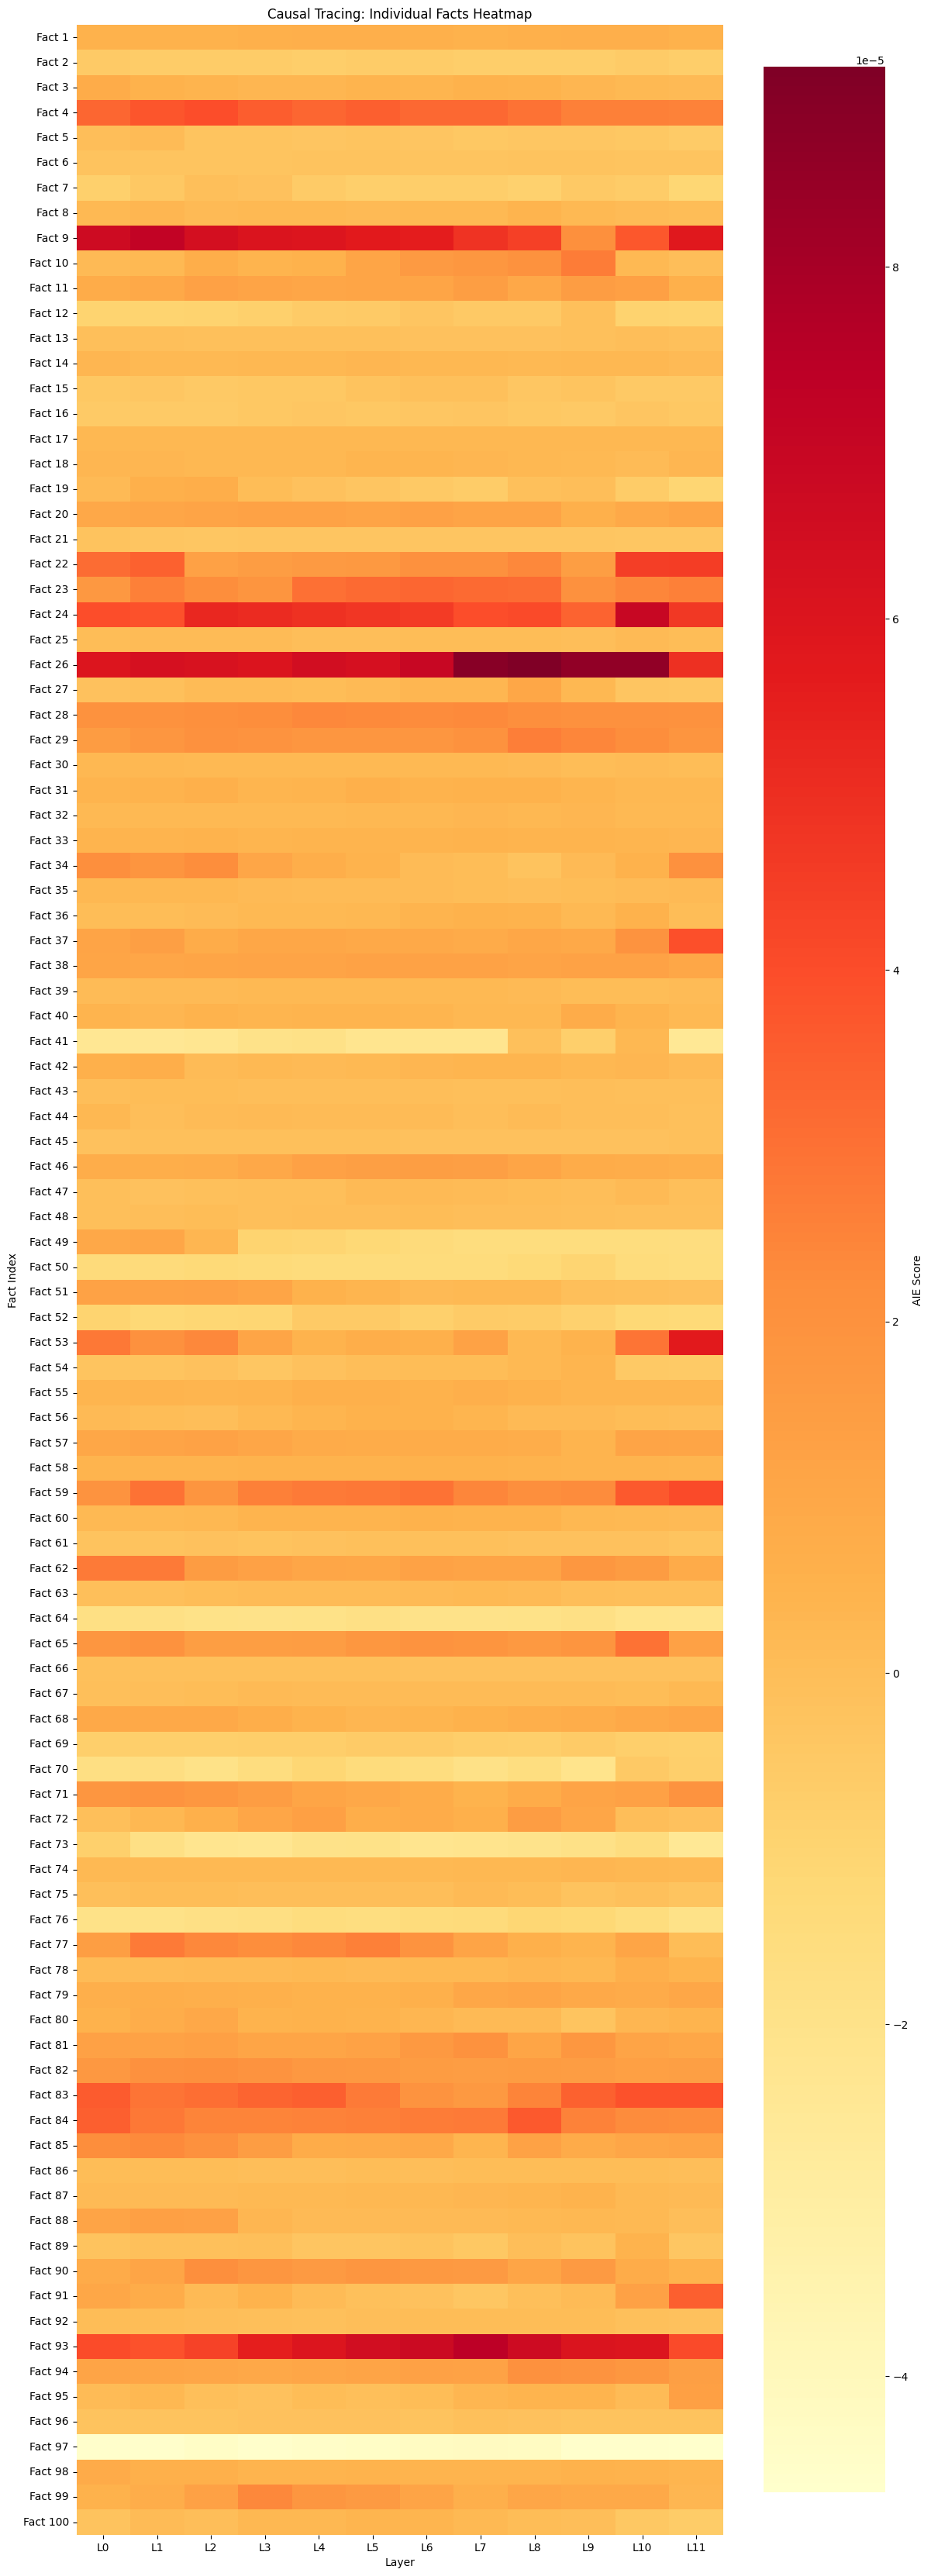

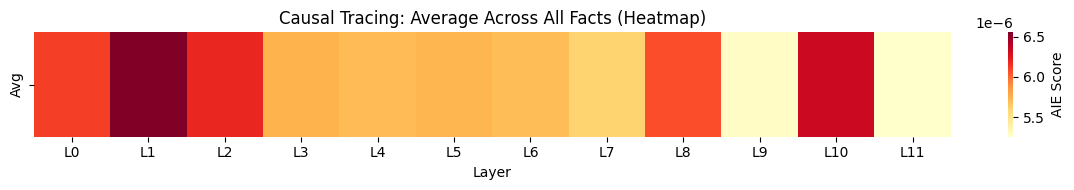

{'peak_layer': 1, 'peak_score': 6.552201238264389e-06, 'early_layer_avg': 6.149493386772066e-06, 'mid_layer_avg': 5.682964777463441e-06, 'late_layer_avg': 5.733964182127239e-06, 'total_impact': 7.026568938545098e-05}


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-FT-Language-EN'
config = model_configs_en[model_label]

print(f"\n=== {model_label} (EN): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_en, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_EN_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_EN_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_EN_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-FT-Semantic-EN


=== BERT-FT-Semantic-EN (EN): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [01:31<00:00,  1.09it/s]


Completed 100 facts. Average scores stored.


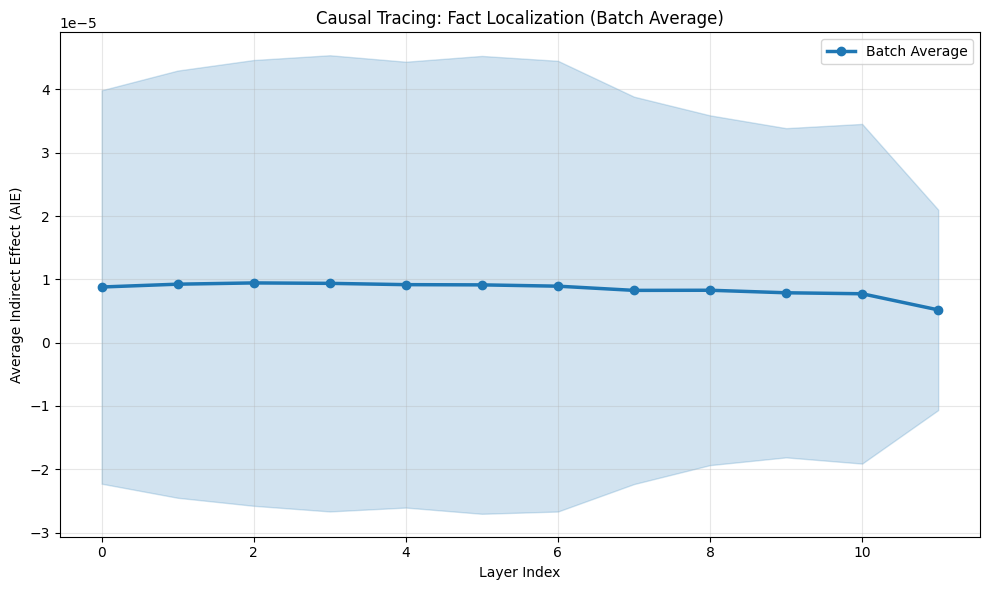

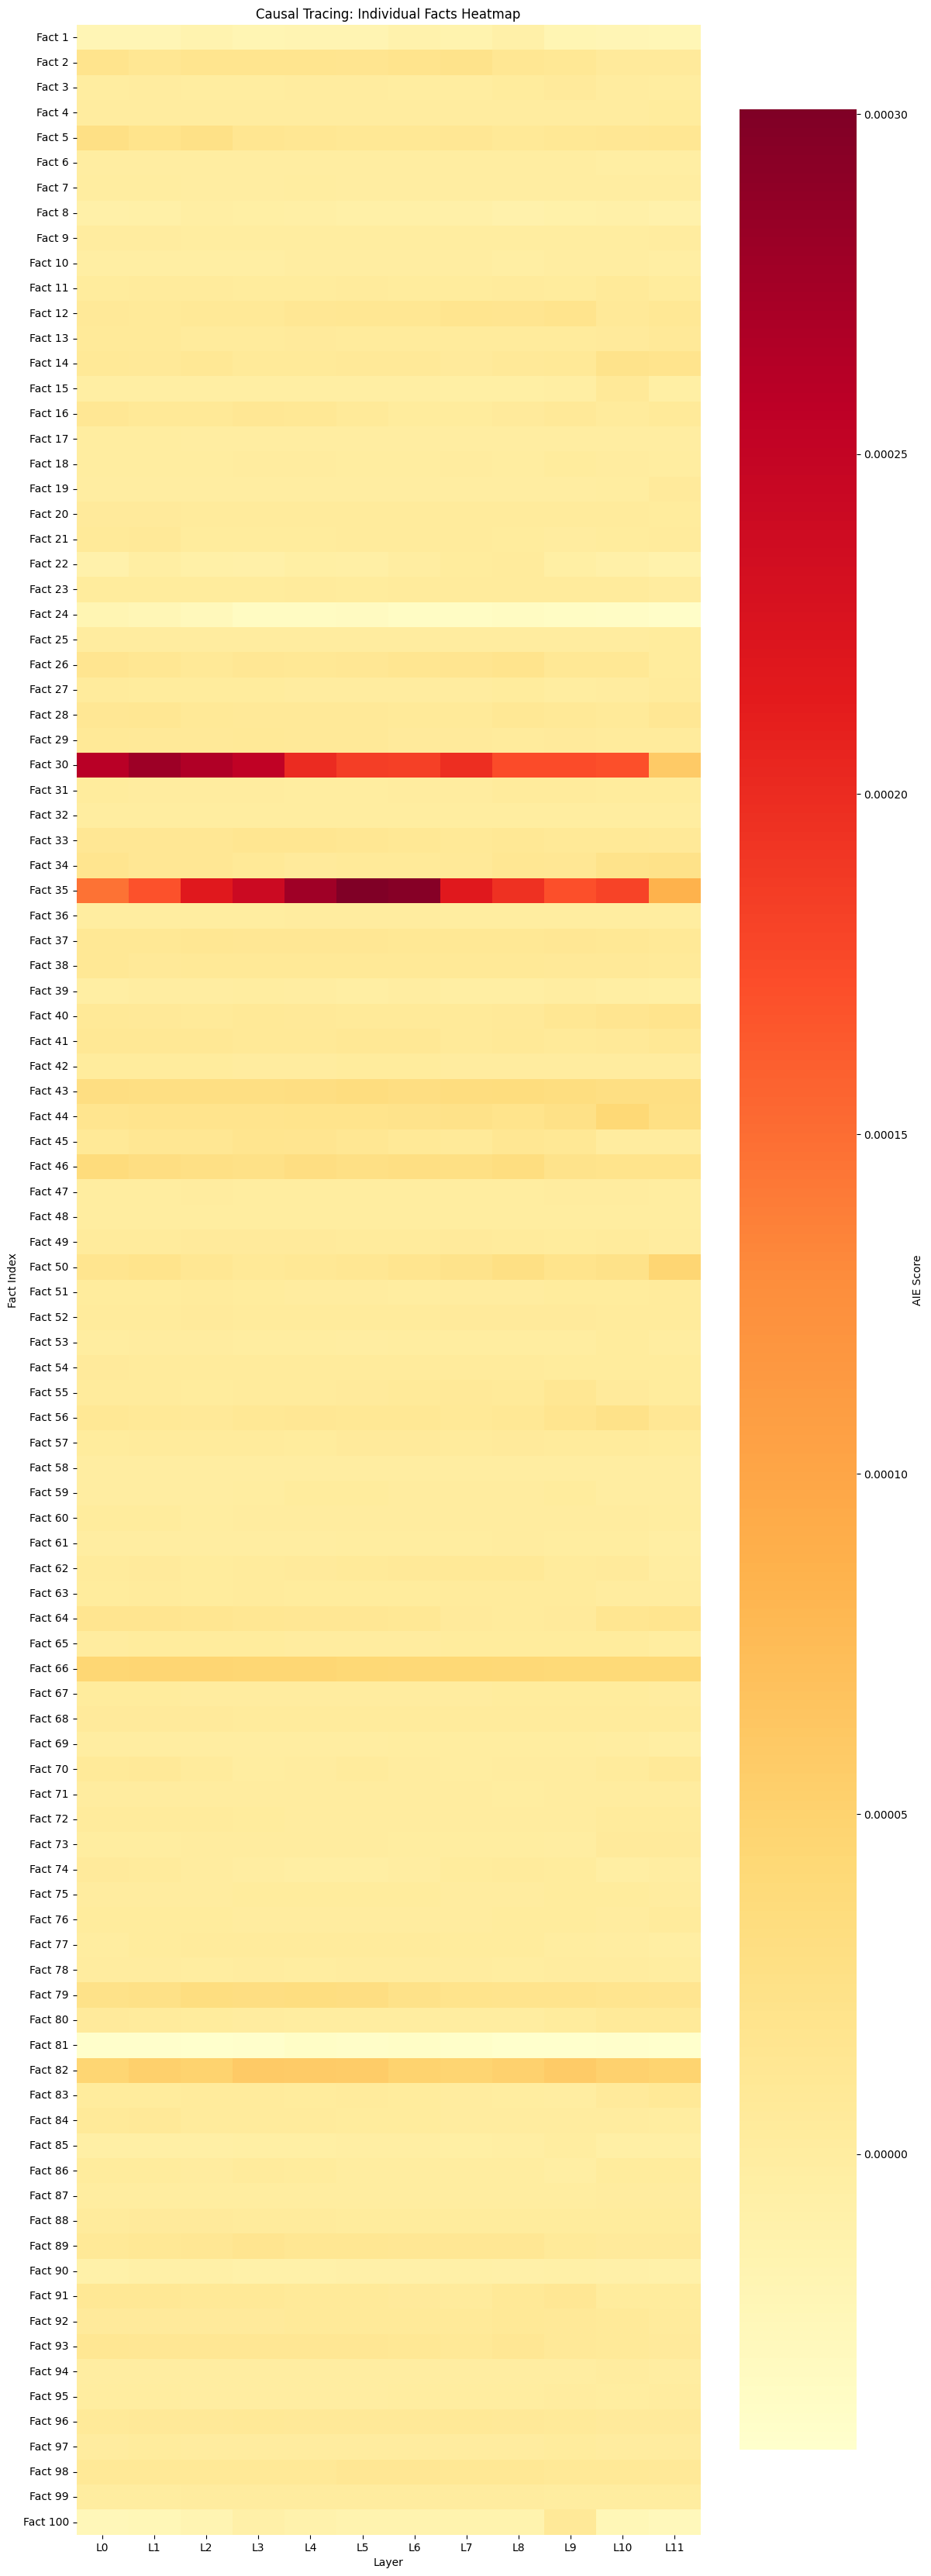

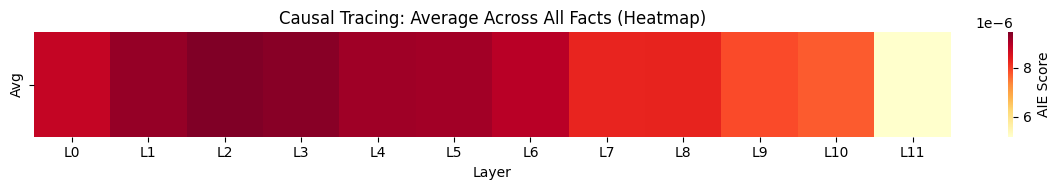

{'peak_layer': 2, 'peak_score': 9.44005396911507e-06, 'early_layer_avg': 9.211658780486687e-06, 'mid_layer_avg': 8.871539558811035e-06, 'late_layer_avg': 7.268805496437378e-06, 'total_impact': 0.0001014080153429404}


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-FT-Semantic-EN'
config = model_configs_en[model_label]

print(f"\n=== {model_label} (EN): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_en, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_EN_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_EN_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_EN_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-FT-Whole-EN


=== BERT-FT-Whole-EN (EN): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [01:31<00:00,  1.09it/s]


Completed 100 facts. Average scores stored.


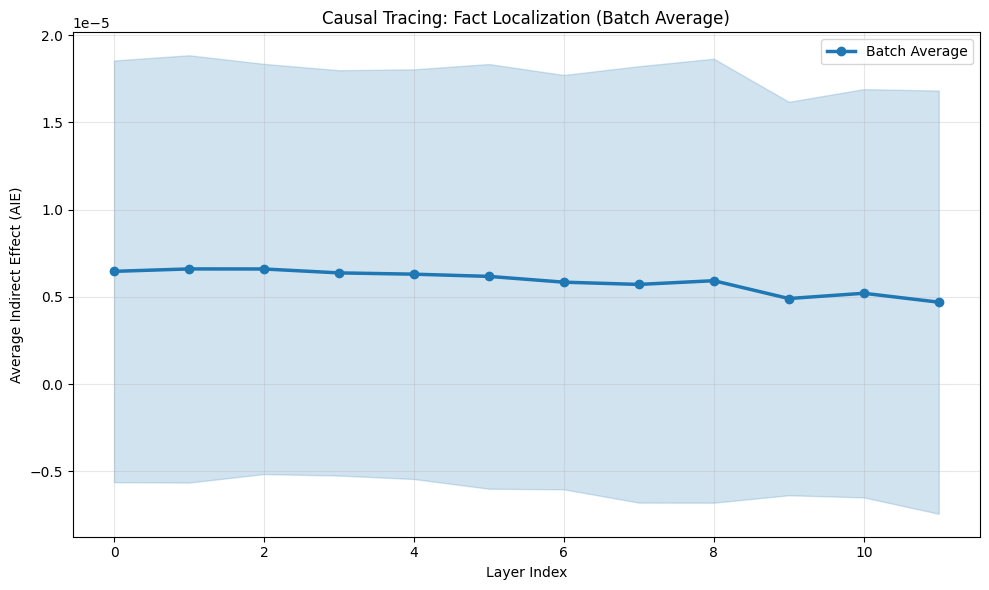

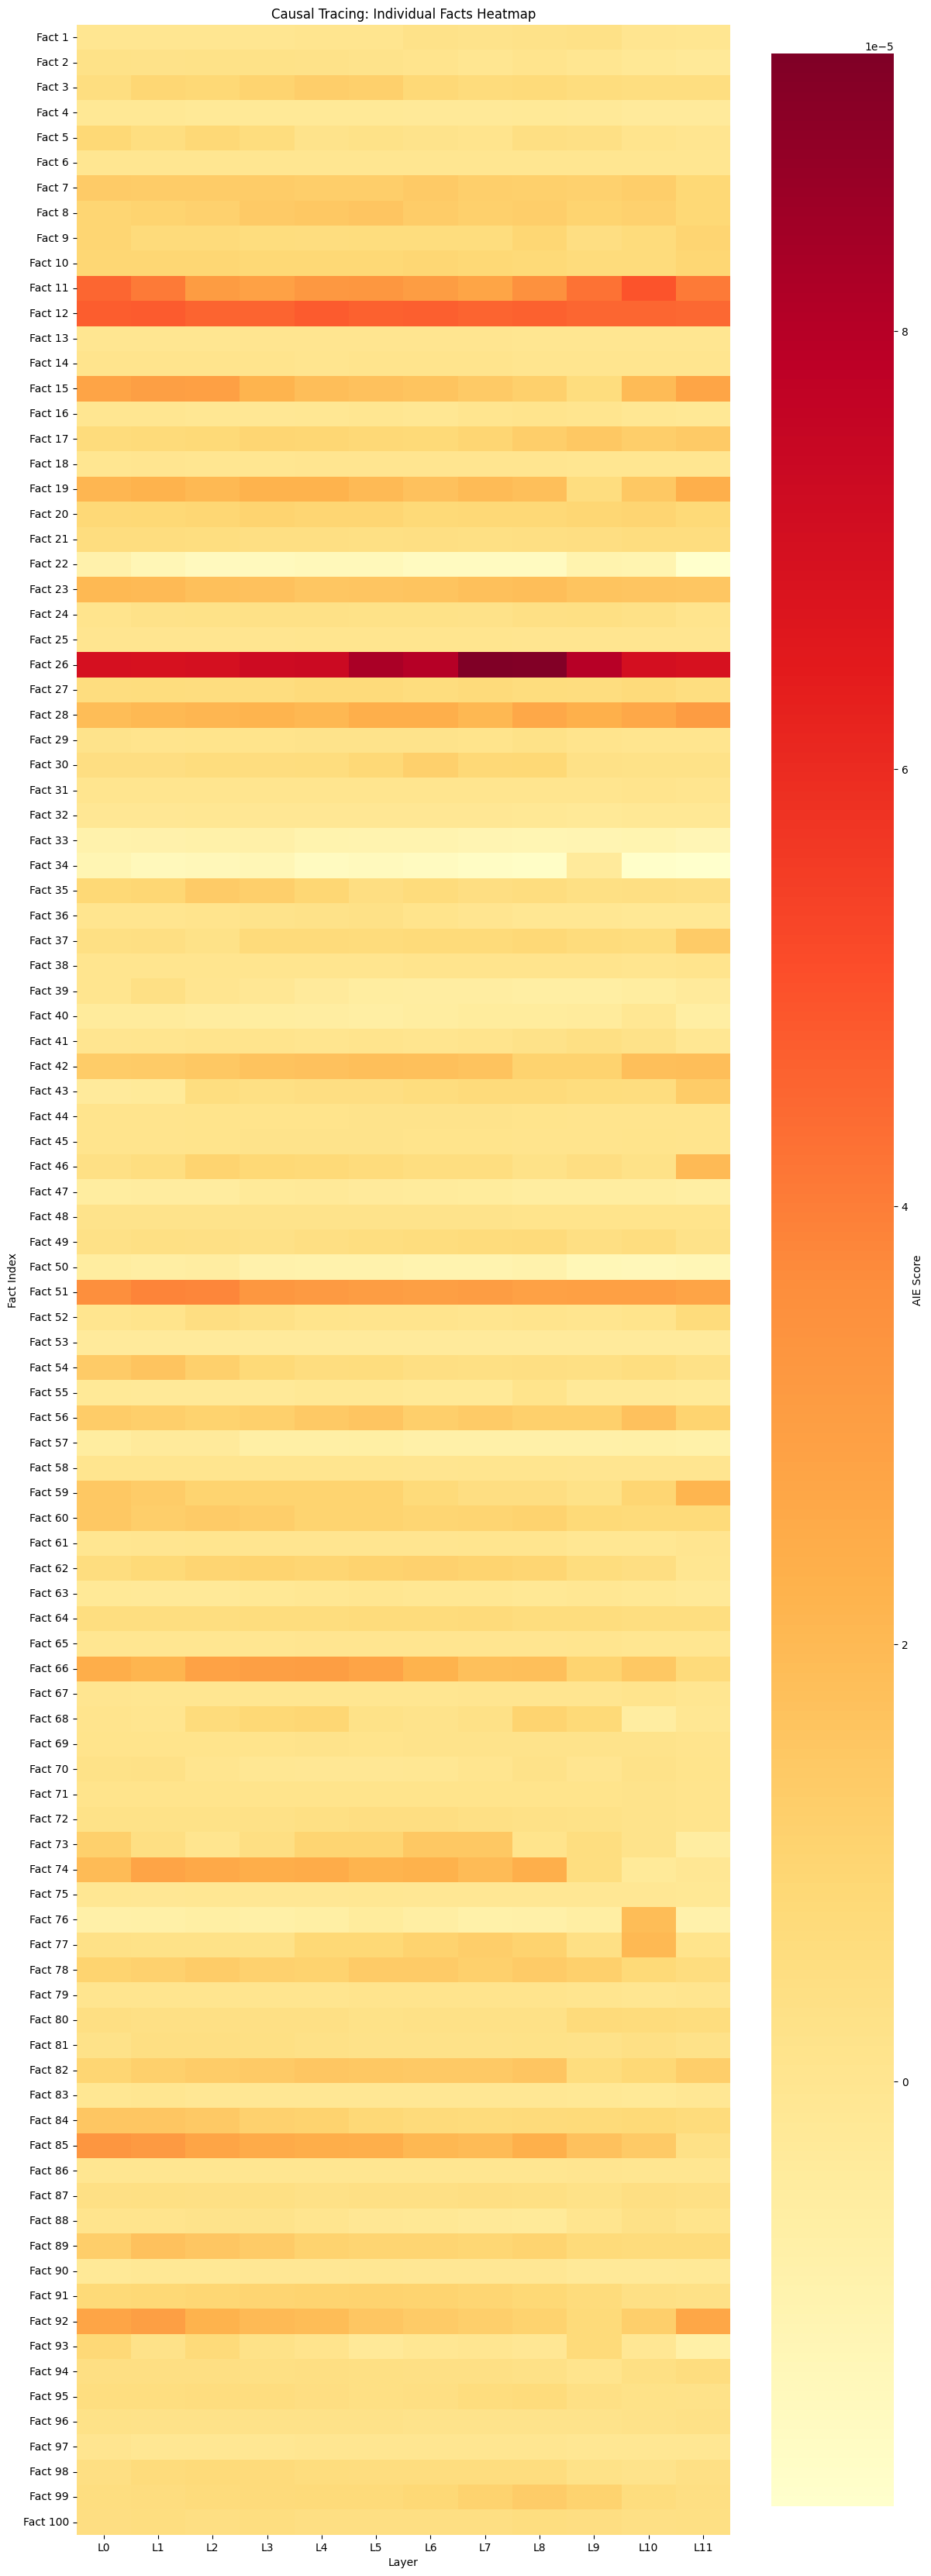

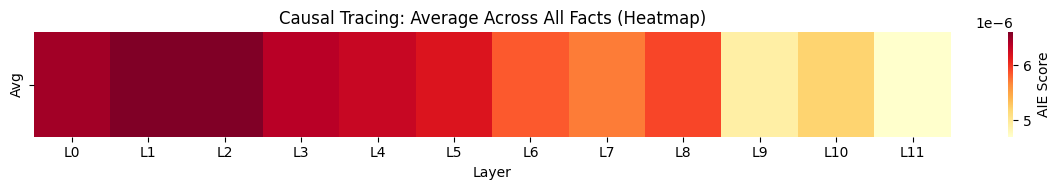

{'peak_layer': 1, 'peak_score': 6.603832775340381e-06, 'early_layer_avg': 6.511287850514692e-06, 'mid_layer_avg': 6.009518268115246e-06, 'late_layer_avg': 5.184874402743846e-06, 'total_impact': 7.082272208549514e-05}


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-FT-Whole-EN'
config = model_configs_en[model_label]

print(f"\n=== {model_label} (EN): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_en, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_EN_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_EN_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_EN_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-Base-ZH


=== BERT-Base-ZH (ZH): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [02:05<00:00,  1.25s/it]


Completed 100 facts. Average scores stored.


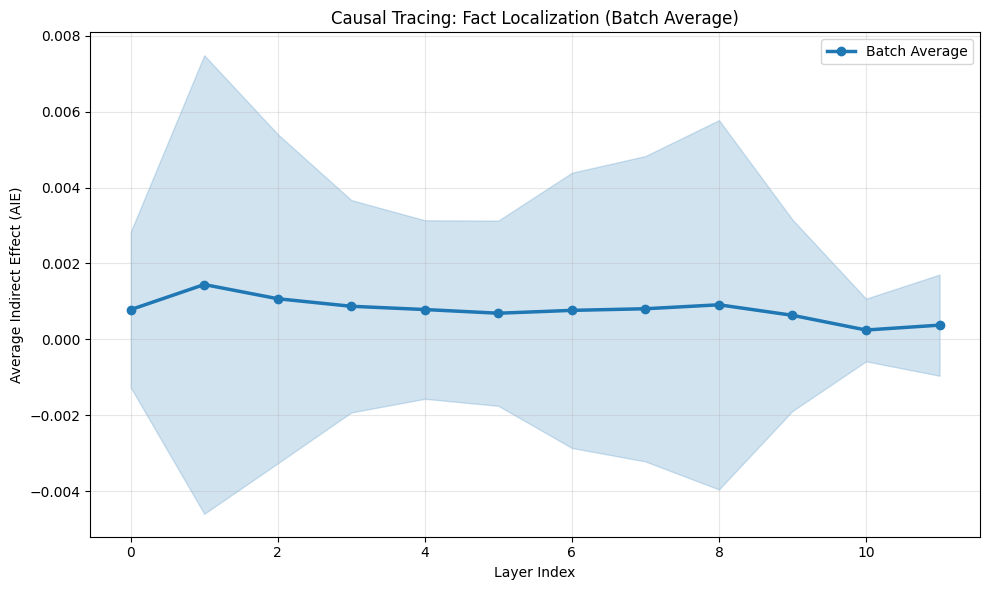

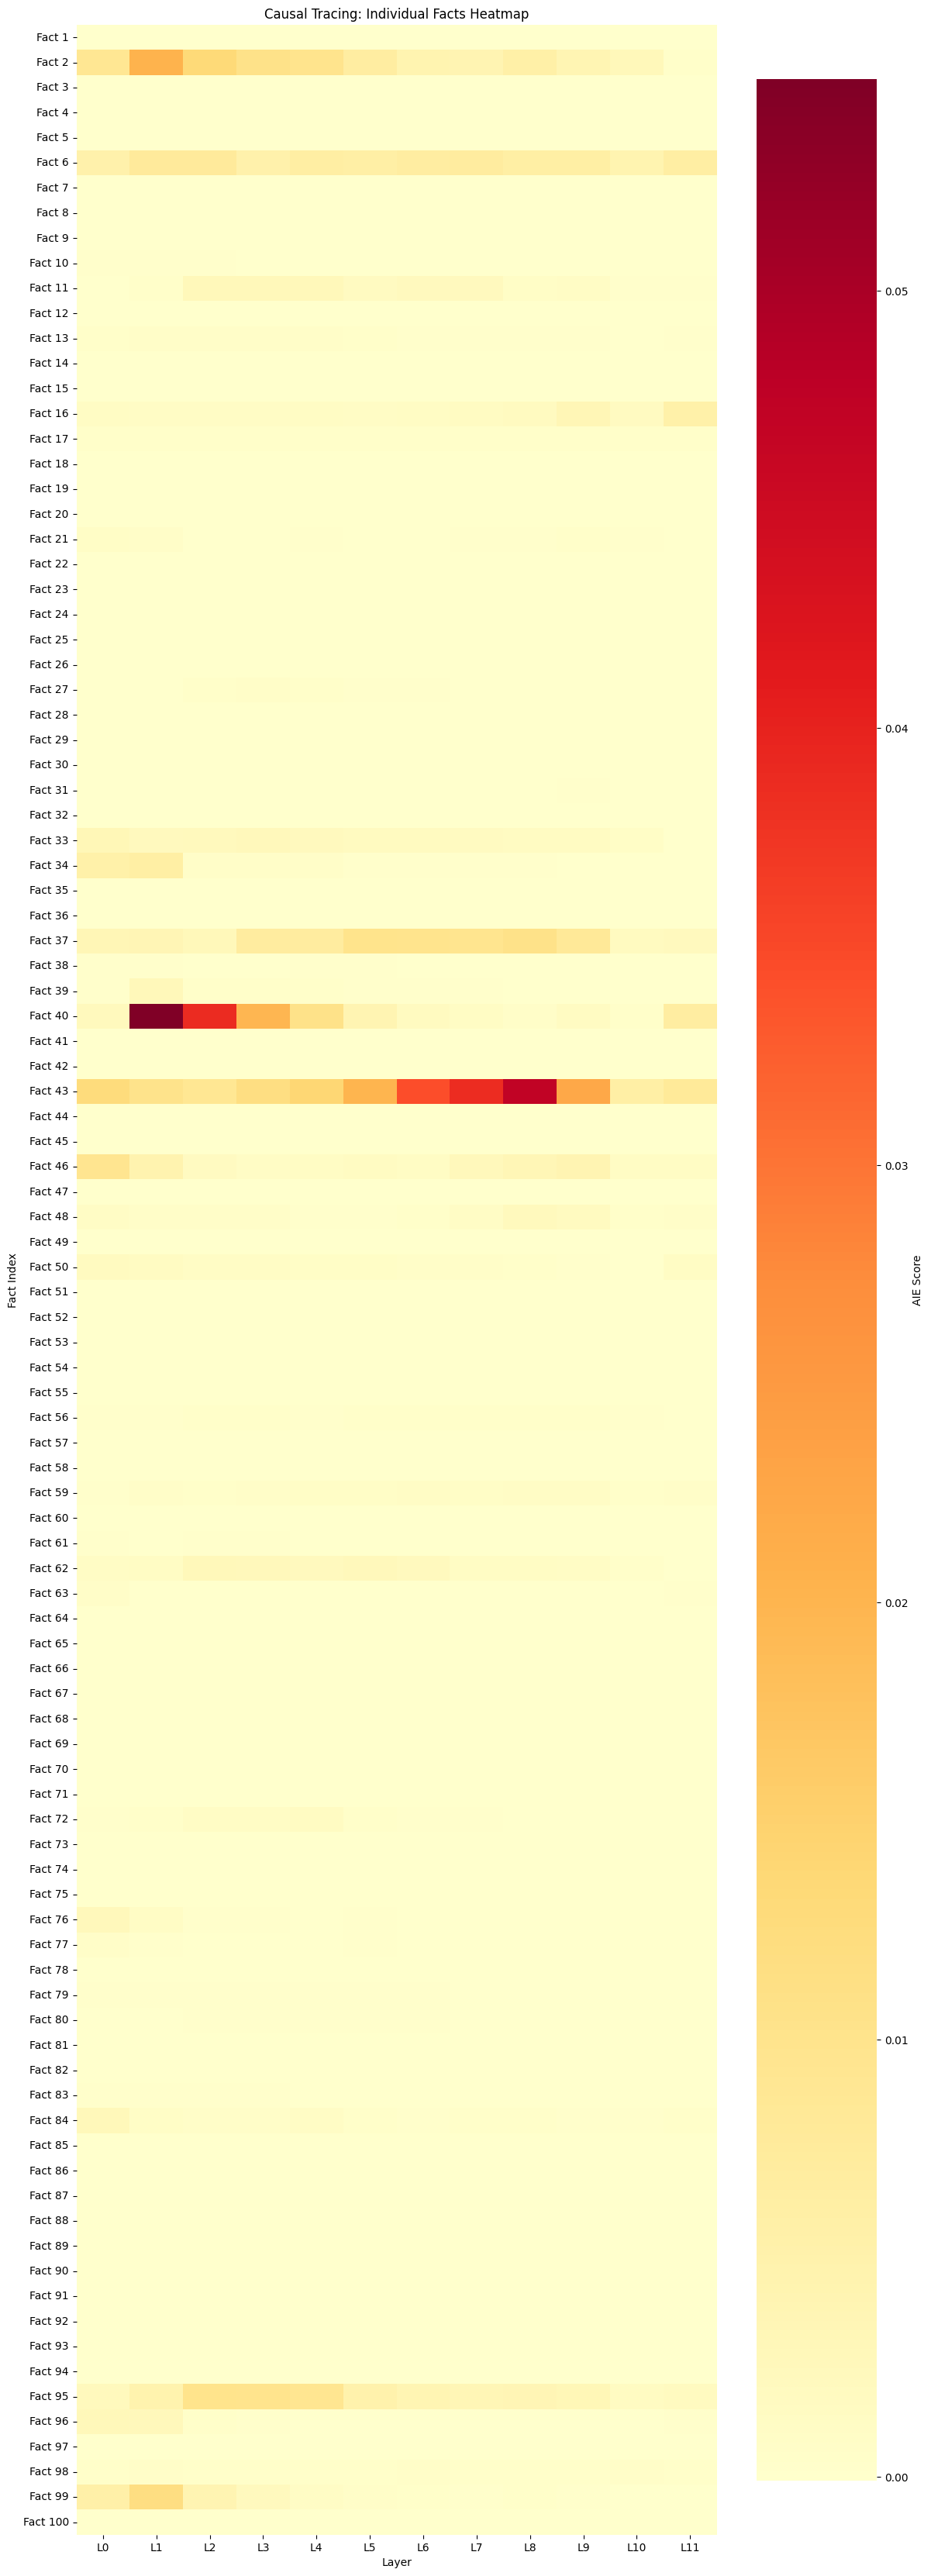

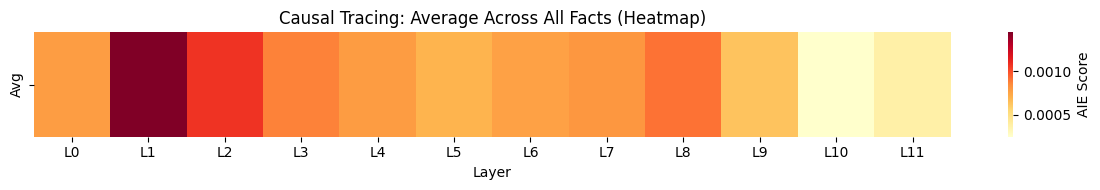

{'peak_layer': 1, 'peak_score': 0.001445445427260758, 'early_layer_avg': 0.0010432091070691953, 'mid_layer_avg': 0.0007620117207516798, 'late_layer_avg': 0.0005421204869188258, 'total_impact': 0.009389365258958804}


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-Base-ZH'
config = model_configs_zh[model_label]

print(f"\n=== {model_label} (ZH): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_zh, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_ZH_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-FT-Language-ZH


=== BERT-FT-Language-ZH (ZH): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [02:05<00:00,  1.25s/it]


Completed 100 facts. Average scores stored.


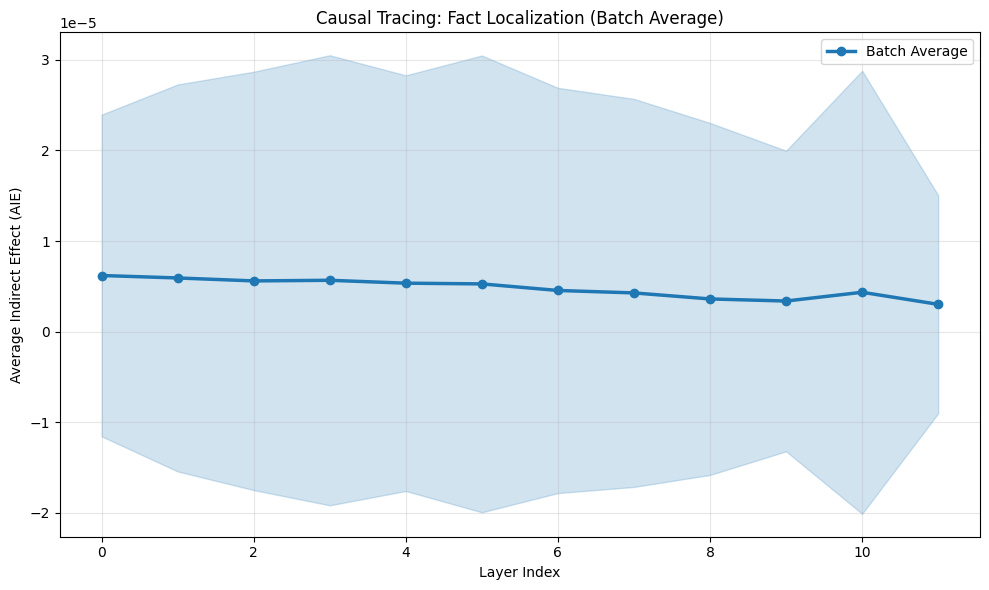

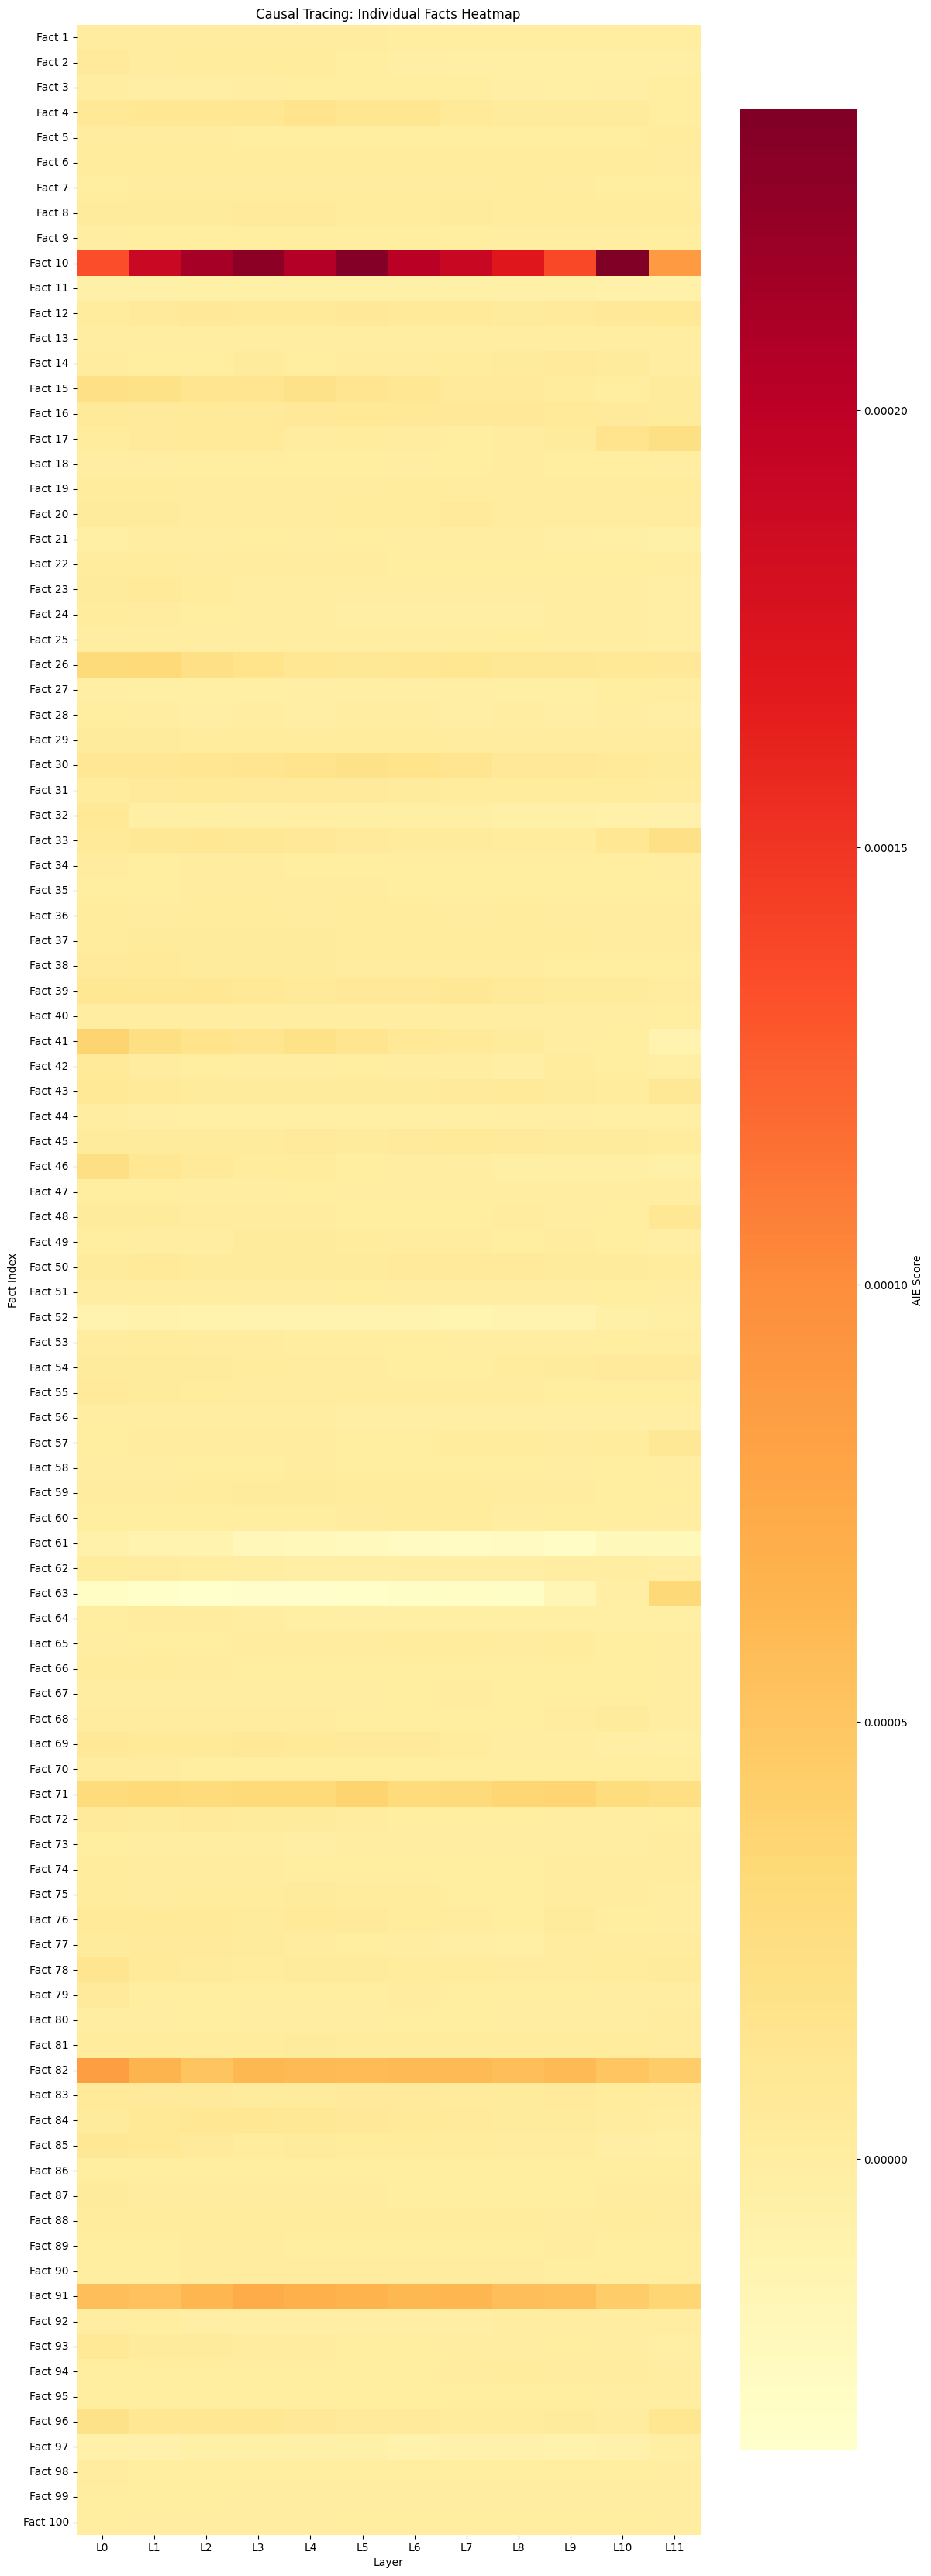

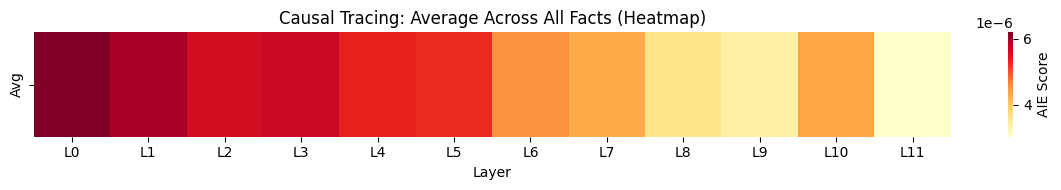

{'peak_layer': 0, 'peak_score': 6.19875087835453e-06, 'early_layer_avg': 5.849965035054082e-06, 'mid_layer_avg': 4.862792604996001e-06, 'late_layer_avg': 3.590832374982256e-06, 'total_impact': 5.721436006012935e-05}


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-FT-Language-ZH'
config = model_configs_zh[model_label]

print(f"\n=== {model_label} (ZH): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_zh, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_ZH_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-FT-Semantic-ZH


=== BERT-FT-Semantic-ZH (ZH): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [02:04<00:00,  1.25s/it]


Completed 100 facts. Average scores stored.


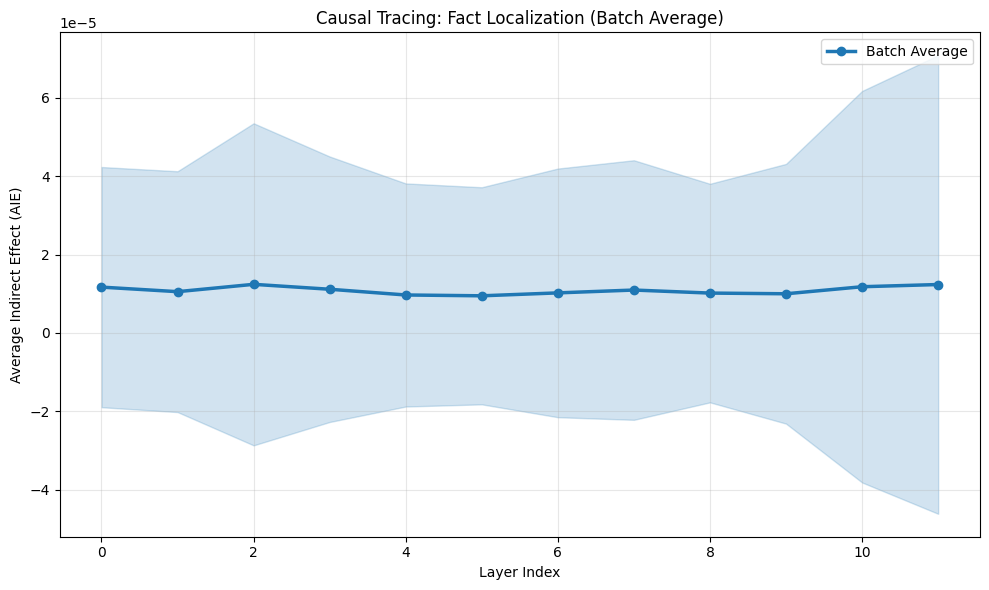

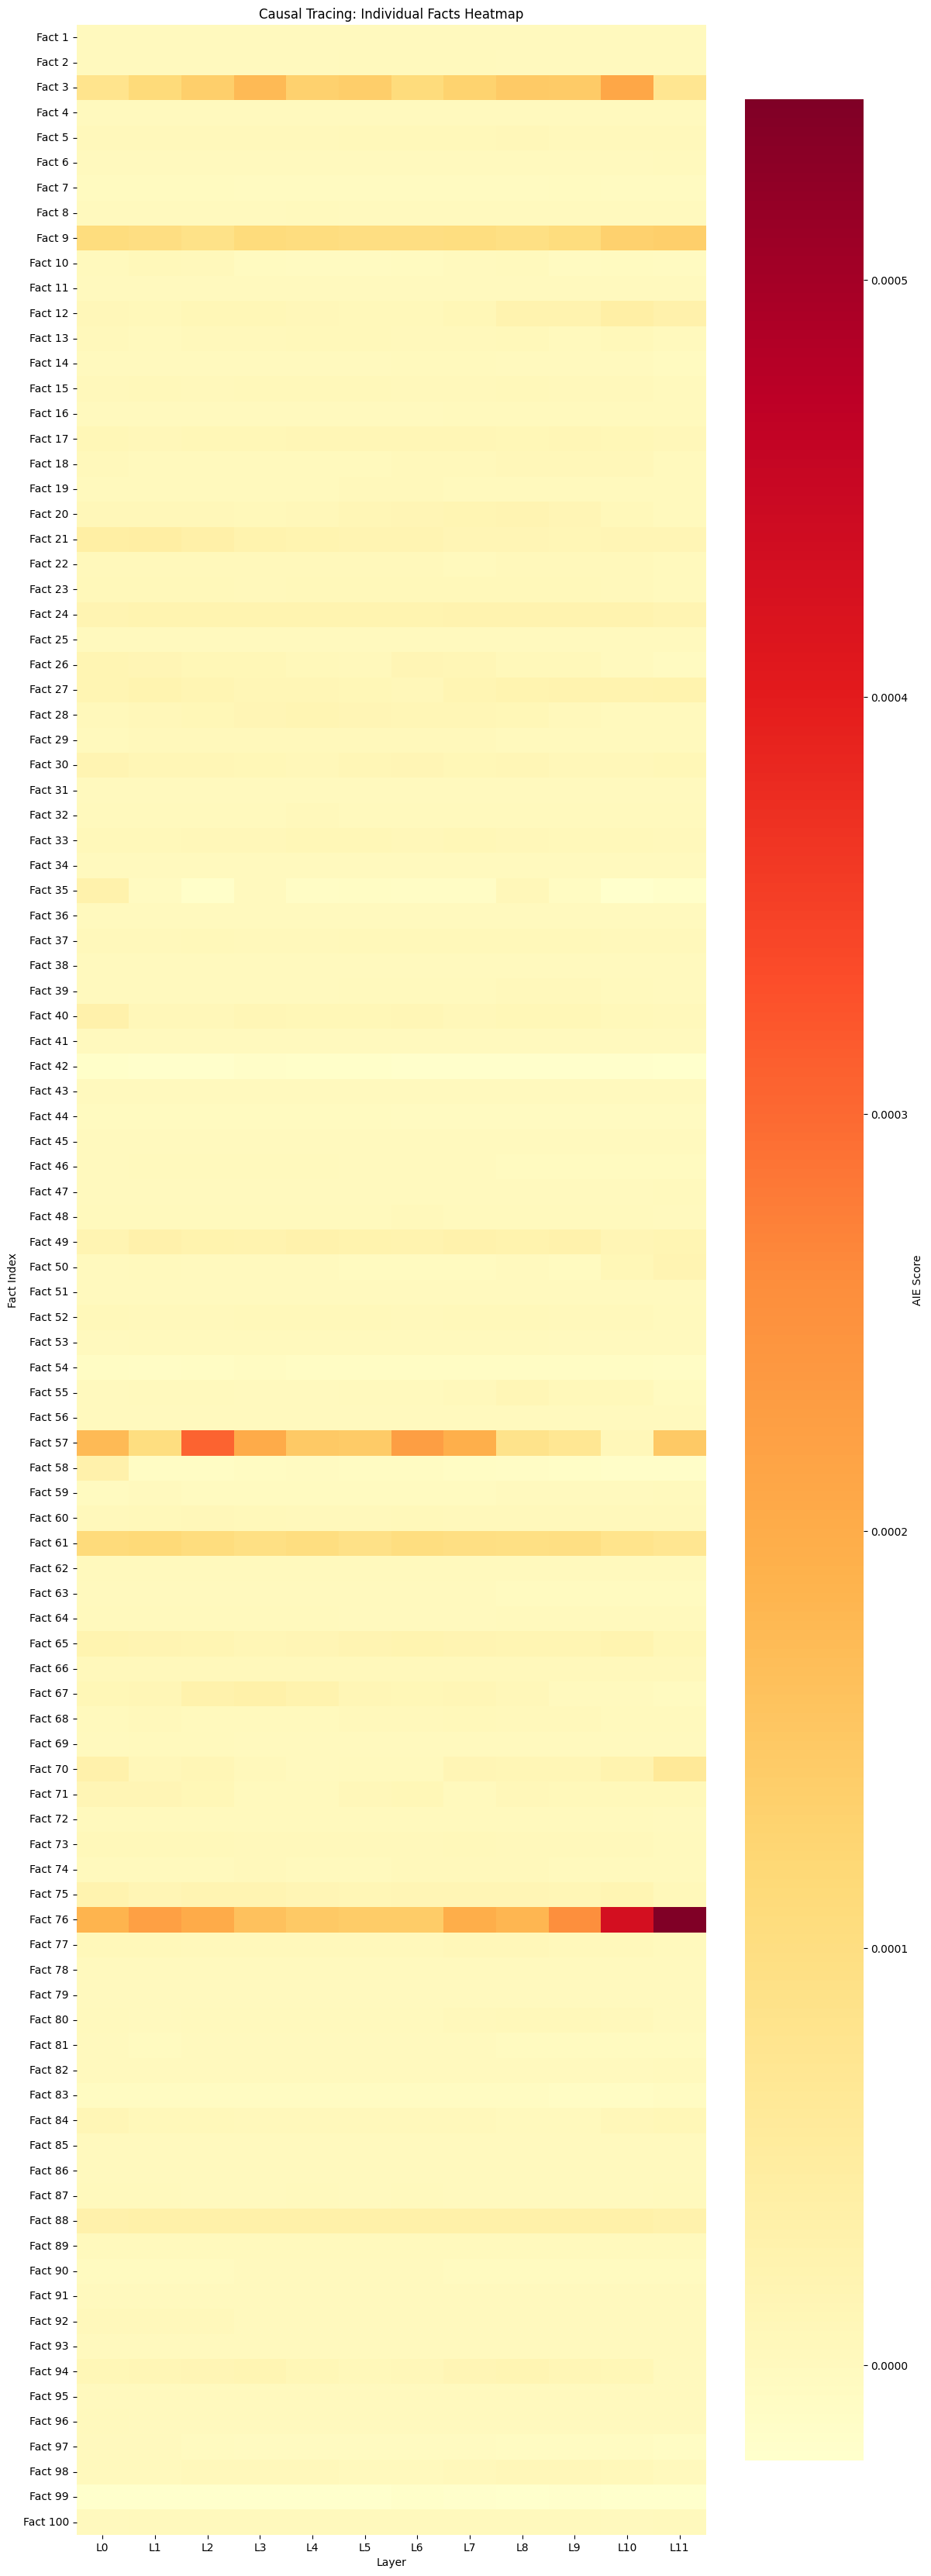

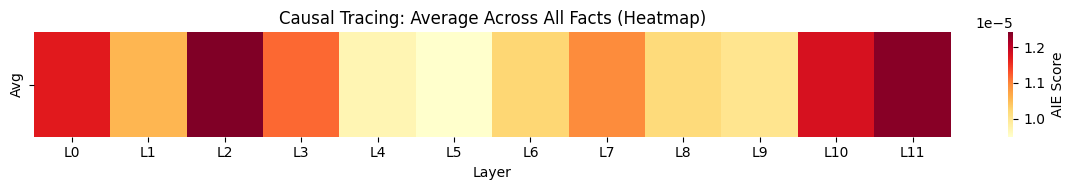

{'peak_layer': 2, 'peak_score': 1.2420419432487505e-05, 'early_layer_avg': 1.1460543873397455e-05, 'mid_layer_avg': 1.0098636914136705e-05, 'late_layer_avg': 1.1094454751429339e-05, 'total_impact': 0.00013061454215585402}


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-FT-Semantic-ZH'
config = model_configs_zh[model_label]

print(f"\n=== {model_label} (ZH): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_zh, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_ZH_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_average.png")

print(analyzer.localization_statistics())


## BERT-FT-Whole-ZH


=== BERT-FT-Whole-ZH (ZH): Capitals (P36) ===
Processing 100 facts...


Processing facts: 100%|██████████| 100/100 [02:04<00:00,  1.24s/it]


Completed 100 facts. Average scores stored.


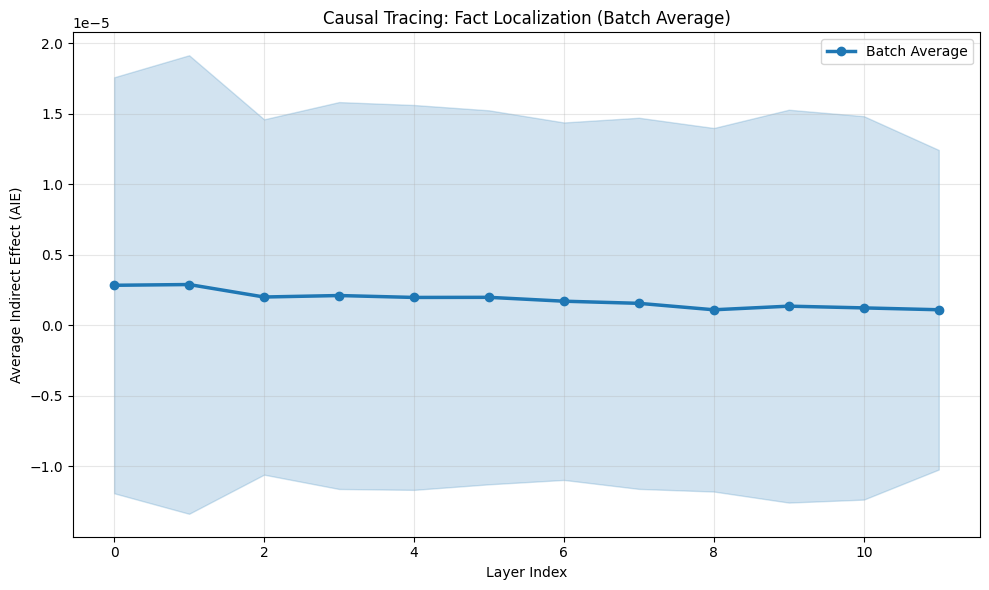

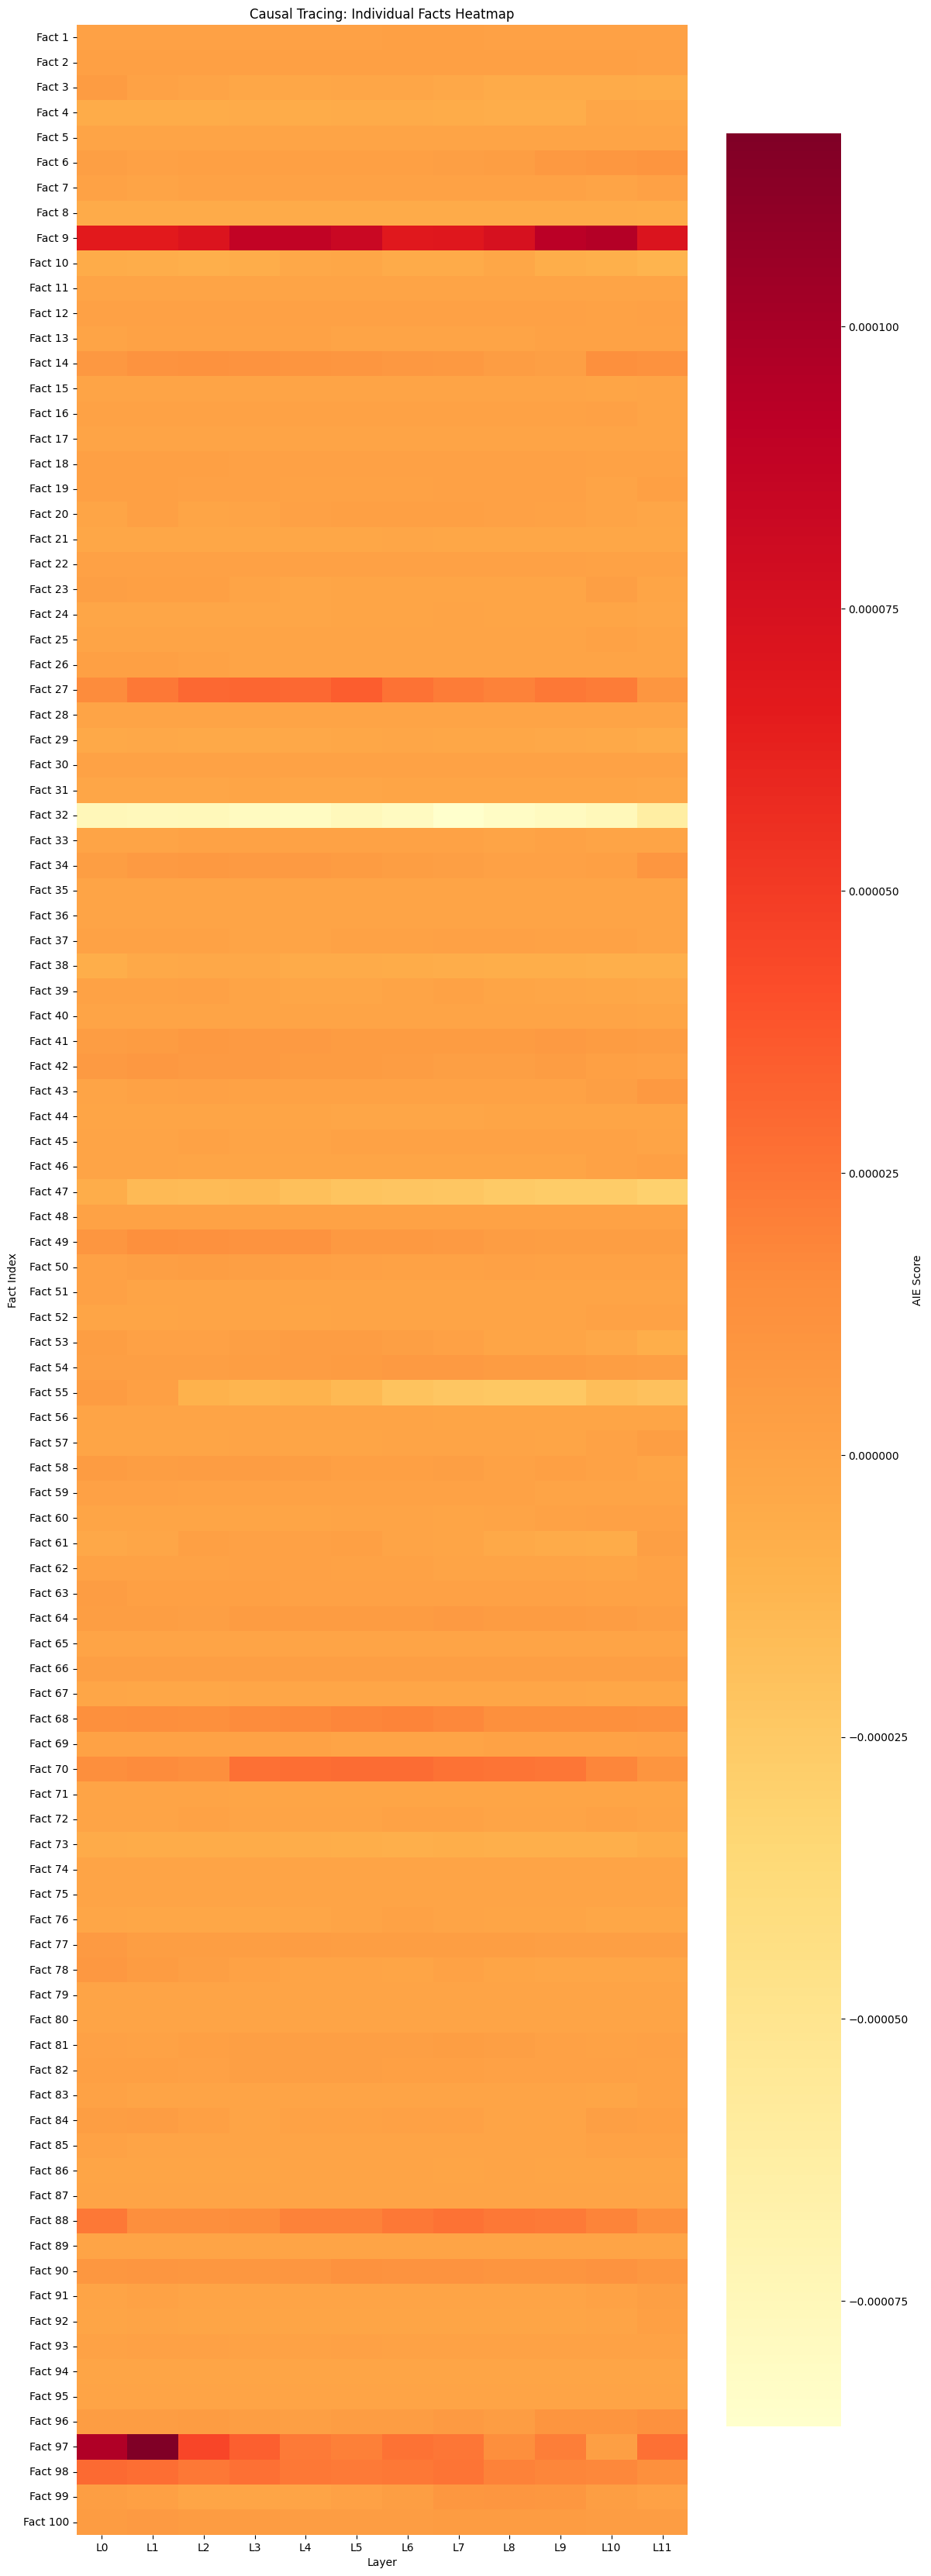

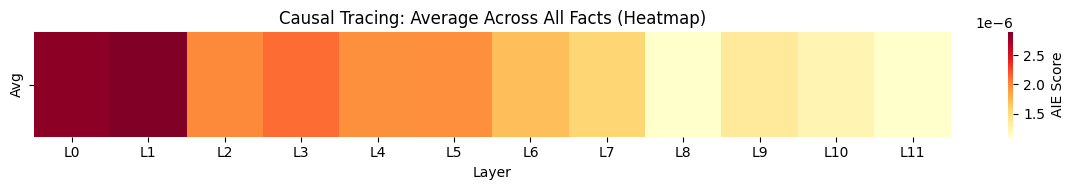

{'peak_layer': 1, 'peak_score': 2.891342100497241e-06, 'early_layer_avg': 2.4619956322879943e-06, 'mid_layer_avg': 1.8074715145388606e-06, 'late_layer_avg': 1.2000522584898476e-06, 'total_impact': 2.187807762126681e-05}


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_label = 'BERT-FT-Whole-ZH'
config = model_configs_zh[model_label]

print(f"\n=== {model_label} (ZH): Capitals (P36) ===")
analyzer = CausalTracingAnalyzer(config['model'], config['tokenizer'], device=device)

analyzer.analyze_batch(first100_facts_capital_zh, noise_scale=0.5)

analyzer.plot_fact_localization(save_path=f"{model_label}_ZH_P36_line.png")

analyzer.plot_individual_facts_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_individual.png")

analyzer.plot_average_heatmap(save_path=f"{model_label}_ZH_P36_heatmap_average.png")

print(analyzer.localization_statistics())
